# 08 - Code Challenge: Three-Class Qwerties

**Section:** ANNs | **Prereqs:** `ANNs/DepthVsBreadth.ipynb` | **Next:** `FNNs/MNIST.ipynb`

Consolidation exercise: the qwerties data with three clusters instead of two,
then a sweep over hidden-layer width from 1 to 128 units.

**The multiclass checklist** (same as Iris, worth internalising):
output units = number of classes, no final activation, `CrossEntropyLoss`,
integer labels, `argmax` for the prediction.

**The width sweep** answers 'how many units do I need?' empirically: accuracy
climbs steeply for the first few units, then flattens. Past that point extra
width only adds parameters, training time, and overfitting risk.

# Classify three data points

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import torch

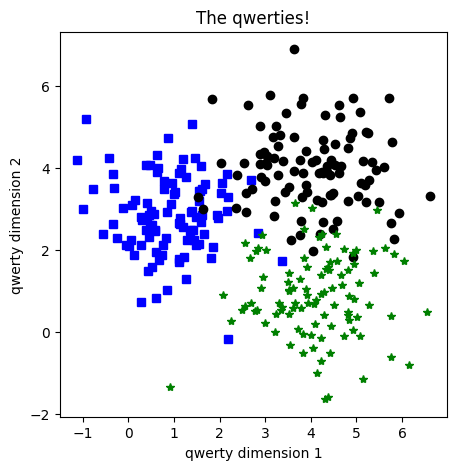

In [2]:
# Three Gaussian clusters, labelled 0/1/2. Two of them overlap noticeably -
# so perfect accuracy is not achievable and roughly 90% is a good score.
nPerClust = 100
blur = 1

A = [  1, 3]
B = [  4, 4]
C = [  4, 1 ]

# generate data
a = [ A[0]+np.random.randn(nPerClust)*blur , A[1]+np.random.randn(nPerClust)*blur ]
b = [ B[0]+np.random.randn(nPerClust)*blur , B[1]+np.random.randn(nPerClust)*blur ]
c = [ C[0]+np.random.randn(nPerClust)*blur , C[1]+np.random.randn(nPerClust)*blur ]

# true labels
labels_np = np.concatenate((
    np.zeros(nPerClust),
    np.ones(nPerClust),
    np.full(nPerClust, 2)
))

# concatanate into a matrix
data_np = np.hstack((a,b,c)).T

# convert to a pytorch tensor
data = torch.tensor(data_np).float()
labels = torch.tensor(labels_np).float()

# show the data
fig = plt.figure(figsize=(5,5))
plt.plot(data[np.where(labels==0)[0],0],data[np.where(labels==0)[0],1],'bs')
plt.plot(data[np.where(labels==1)[0],0],data[np.where(labels==1)[0],1],'ko')
plt.plot(data[np.where(labels == 2)[0],0], data[np.where(labels==2)[0],1], 'g*')

plt.title('The qwerties!')
plt.xlabel('qwerty dimension 1')
plt.ylabel('qwerty dimension 2')
plt.show()

In [3]:
# 2 -> 24 -> 24 -> 3. Wider than strictly needed, and no final activation:
# CrossEntropyLoss consumes raw logits.
model = nn.Sequential(
    nn.Linear(2,24),
    nn.ReLU(),
    nn.Linear(24,24),
    nn.ReLU(),
    nn.Linear(24,3)
)

model

Sequential(
  (0): Linear(in_features=2, out_features=24, bias=True)
  (1): ReLU()
  (2): Linear(in_features=24, out_features=24, bias=True)
  (3): ReLU()
  (4): Linear(in_features=24, out_features=3, bias=True)
)

In [4]:
# CrossEntropyLoss + SGD.
lossFunc = nn.CrossEntropyLoss()
epochs = 10000

optimizer = torch.optim.SGD(model.parameters(),lr=0.01)
optimizer

SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)

In [5]:
# Training loop with accuracy logged per epoch.
# labels.long() casts on the fly - CrossEntropyLoss rejects float targets.
# Accuracy is computed from `yhat`, i.e. from BEFORE this epoch's update, so
# it lags the loss by one step. Harmless over 10000 epochs.
losses = torch.zeros(epochs)
accuracy = []


for epoch in range(epochs):

  # Fused froward prop and loss calculations
  yhat = model(data.float())
  loss = lossFunc(yhat,labels.long())
  losses[epoch] = loss

  # Back Prop

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

 # Calculate accuracy

  accloc = (torch.argmax(yhat,axis=1) == labels).float()
  acc = 100*torch.mean(accloc)
  accuracy.append(acc)


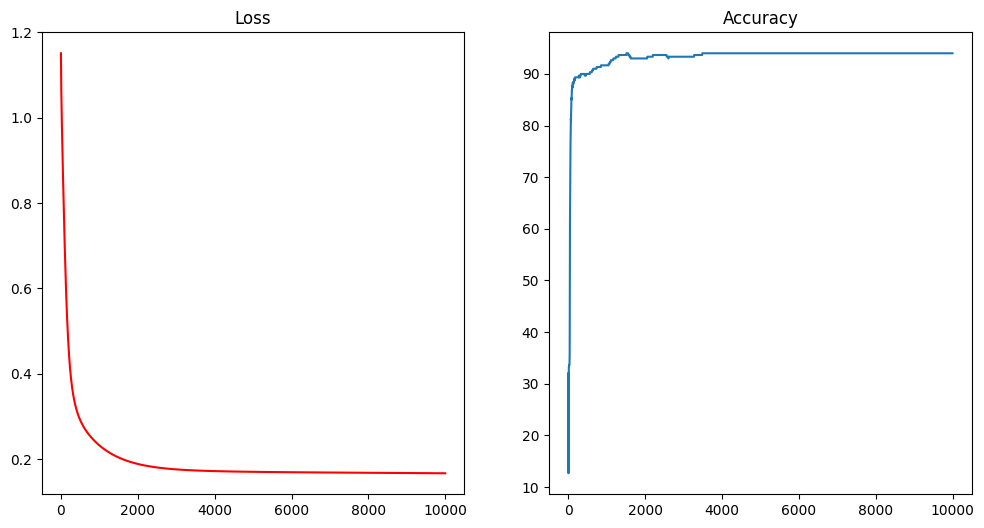

In [6]:
# Loss and accuracy side by side. They should mirror each other; if loss falls
# while accuracy stalls, the model is getting more confident about samples it
# already had right instead of fixing the ones it gets wrong.
fig, ax = plt.subplots(1,2, figsize =(12,6))
ax[0].plot(losses.detach(), 'r')
ax[0].set_title("Loss")

ax[1].plot(accuracy)
ax[1].set_title("Accuracy");

In [7]:
# Final predictions: argmax over the 3 logits gives the predicted class.
predictions = model(data)
predlabels = (torch.argmax(predictions,axis=1)).float()

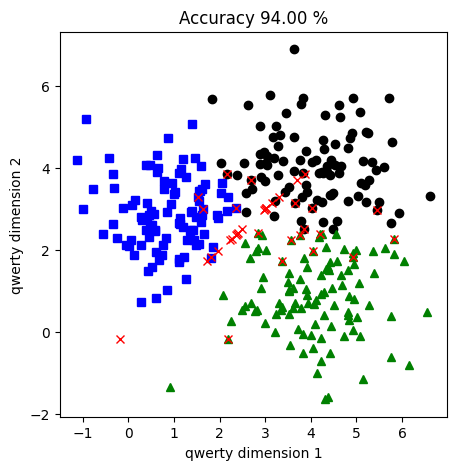

In [8]:
# The decision map. Errors (red x) cluster on the boundary between the two
# overlapping blobs - exactly where the data itself is ambiguous.
fig = plt.figure(figsize=(5,5))
plt.plot(data[np.where(predlabels==0)[0],0],data[np.where(predlabels==0)[0],1],'bs')
plt.plot(data[np.where(predlabels==1)[0],0],data[np.where(predlabels==1)[0],1],'ko')
plt.plot(data[np.where(predlabels == 2)[0],0], data[np.where(predlabels==2)[0],1], 'g^')
plt.plot(data[np.where(predlabels != labels)[0]], data[np.where(predlabels != labels)[0],1], "rx")

plt.title(f'Accuracy {np.max(accuracy):.2f} %')
plt.xlabel('qwerty dimension 1')
plt.ylabel('qwerty dimension 2')
plt.show()

In [9]:
# Parametric experiment: 128 models, hidden width 1 to 128, 1000 epochs each.
# Expect a steep climb over the first few units and a plateau after that.
# Note each model gets a fresh optimizer - reusing one across models would
# leave it holding references to dead parameters.
## Parametric experiment

modelAccuracy = []

for i in range(128):
  model = nn.Sequential(
      nn.Linear(2,(i+1)),
      nn.ReLU(),
      nn.Linear((i+1),(i+1)),
      nn.ReLU(),
      nn.Linear((i+1),3)
  )

  lossFunc = nn.CrossEntropyLoss()
  epochs = 1000

  optimizer = torch.optim.SGD(model.parameters(),lr=0.01)

  for epoch in range(epochs):

  # Fused froward prop and loss calculations
     yhat = model(data.float())

     loss = lossFunc(yhat,labels.long())


  # Back Prop

     optimizer.zero_grad()
     loss.backward()
     optimizer.step()

 # Calculate accuracy
  accloc = (torch.argmax(model(data),axis=1) == labels).float()
  acc = 100*torch.mean(accloc)
  modelAccuracy.append(acc)

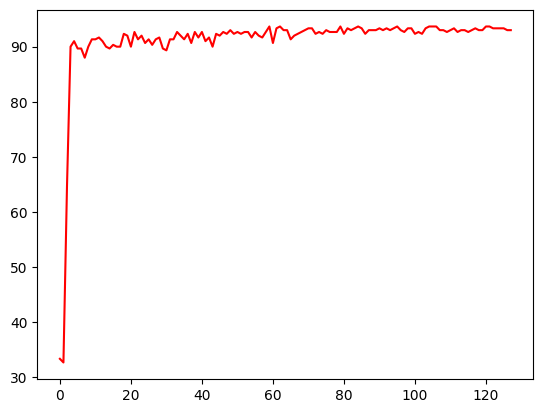

In [10]:
# Accuracy vs width. The plateau is the answer to 'how wide is wide enough?';
# the spikiness on top of it is single-run noise, not a real difference.

plt.plot(modelAccuracy, 'r');
